<a href="https://colab.research.google.com/github/amoghvd/ML-lab-2547211/blob/LAB-4/LAB_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Task 1: Data Preparation
In this step, we bring the data into our notebook and prepare it for our machine learning model.

In [12]:
import pandas as pd
import requests
from io import StringIO


file_id = '1poP5CatfiZGaRbGCAKPGe_wOBCGspDjA'
url = f'https://drive.google.com/uc?id={file_id}'


response = requests.get(url)
df = pd.read_csv(StringIO(response.text))


if 'id' in df.columns.str.lower():
    df = df.drop(df.columns[0], axis=1)

print("Dataset Shape:", df.shape)
display(df.head())

print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Dataset Shape: (569, 32)


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B



Missing values: 0
Duplicate rows: 0


### Feature Scaling
KNN uses distances (like measuring the gap between two points) to make predictions. If one feature has huge numbers (like 'area') and another has tiny numbers (like 'smoothness'), the huge numbers will overpower the measurement. We use `StandardScaler` to put everything on the same scale (mean=0, variance=1) so the model treats every feature fairly.

In [19]:
from sklearn.preprocessing import StandardScaler

# 1. SMART COLUMN FINDER
# Instead of guessing the name, we look for the column that has 'M' or 'B' in it.
diagnosis_col = None
for col in df.columns:
    if df[col].dtype == 'object': # Check only text columns
        if set(df[col].unique()).issubset({'M', 'B'}):
            diagnosis_col = col
            break

# 2. CONVERT TEXT TO NUMBERS
# Computers prefer 0s and 1s. We turn 'M' (Malignant) to 0 and 'B' (Benign) to 1.
df['target'] = df[diagnosis_col].map({'M': 0, 'B': 1})

# 3. SELECT FEATURES (X)
# We pick all the numeric measurements (like radius, texture) to use for prediction.
# We exclude the 'target' we just made and the original text column.
X = df.select_dtypes(include=['float64', 'int64']).drop(['target'], axis=1, errors='ignore')

# 4. CLEAN UP
# Some CSVs have an empty column at the end; if 'Unnamed' is there, we toss it out.
X = X.loc[:, ~X.columns.str.contains('^Unnamed')]

y = df['target']

# 5. EQUALIZING THE SCALE
# Imagine comparing a height in meters (1.8) to a weight in grams (80,000).
# The weight would 'bully' the height in math. StandardScaler makes them all equal.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Found the diagnosis in: {diagnosis_col}")
print(f"Ready! We are using {X.shape[1]} different measurements to train our model.")

Found the diagnosis in: y
Ready! We are using 30 different measurements to train our model.


### Task 2: Train-Test Split Analysis
We divide our data into two parts: one for the model to study (Training) and one for us to test its knowledge (Testing). This prevents the model from just 'memorizing' the answers.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

splits = [0.2, 0.3, 0.1]
results = {}

for test_size in splits:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    accuracy = accuracy_score(y_test, knn.predict(X_test))
    label = f"{int((1-test_size)*100)}:{int(test_size*100)}"
    results[label] = accuracy

for ratio, acc in results.items():
    print(f"Split {ratio} -> Accuracy: {acc:.4f}")

Split 80:20 -> Accuracy: 0.9298
Split 70:30 -> Accuracy: 0.9591
Split 90:10 -> Accuracy: 0.9298


When we use a 90:10 split, the model has more data to learn from, but the test results might be less reliable because the test set is very small. A 70:30 split gives us a very reliable test score but might leave the model 'hungry' for more training data. The 80:20 split is usually the 'sweet spot' for a balance between learning and testing.

### Task 3: KNN Model with Heuristic K Selection
We start with a mathematical guess: $K = \sqrt{n}$, where $n$ is the number of patients in our training set. This gives us a balanced starting point that isn't too small (which might be sensitive to noise) or too large (which might ignore local patterns).

Heuristic K (sqrt of 455): 21


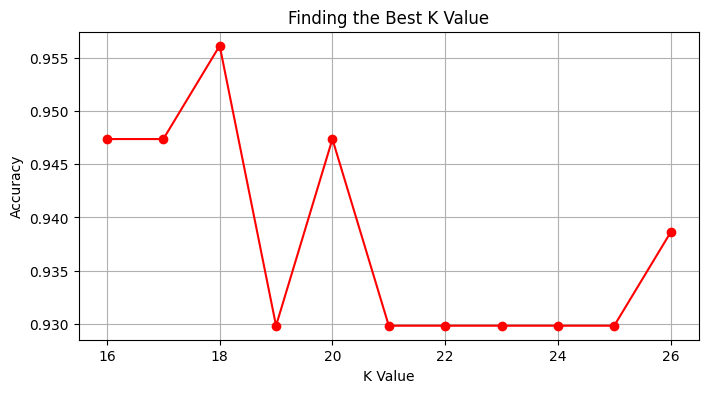

In [26]:
import numpy as np
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

n = len(X_train)
heuristic_k = int(np.sqrt(n))
print(f"Heuristic K (sqrt of {n}):", heuristic_k)

k_values = range(heuristic_k - 5, heuristic_k + 6)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies.append(acc)

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker='o', color='red')
plt.title('Finding the Best K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

The chart above shows us how the model's accuracy changes as we tweak $K$. We are looking for the 'peak'—the $K$ value where the model is most accurate at identifying whether a tumor is malignant or benign.

### Task 3.3: Distance Metrics and Decision Boundaries

#### Distance Metrics
1. **Euclidean Distance**: The 'as-the-crow-flies' straight-line distance. Best when features are continuous and normally distributed.
2. **Manhattan Distance**: The 'city block' distance (sum of absolute differences). Best when dealing with high-dimensional data or when features are discrete/categorical.

#### Decision Boundaries
We will plot how the model separates classes using two primary features: 'mean radius' and 'mean texture'.

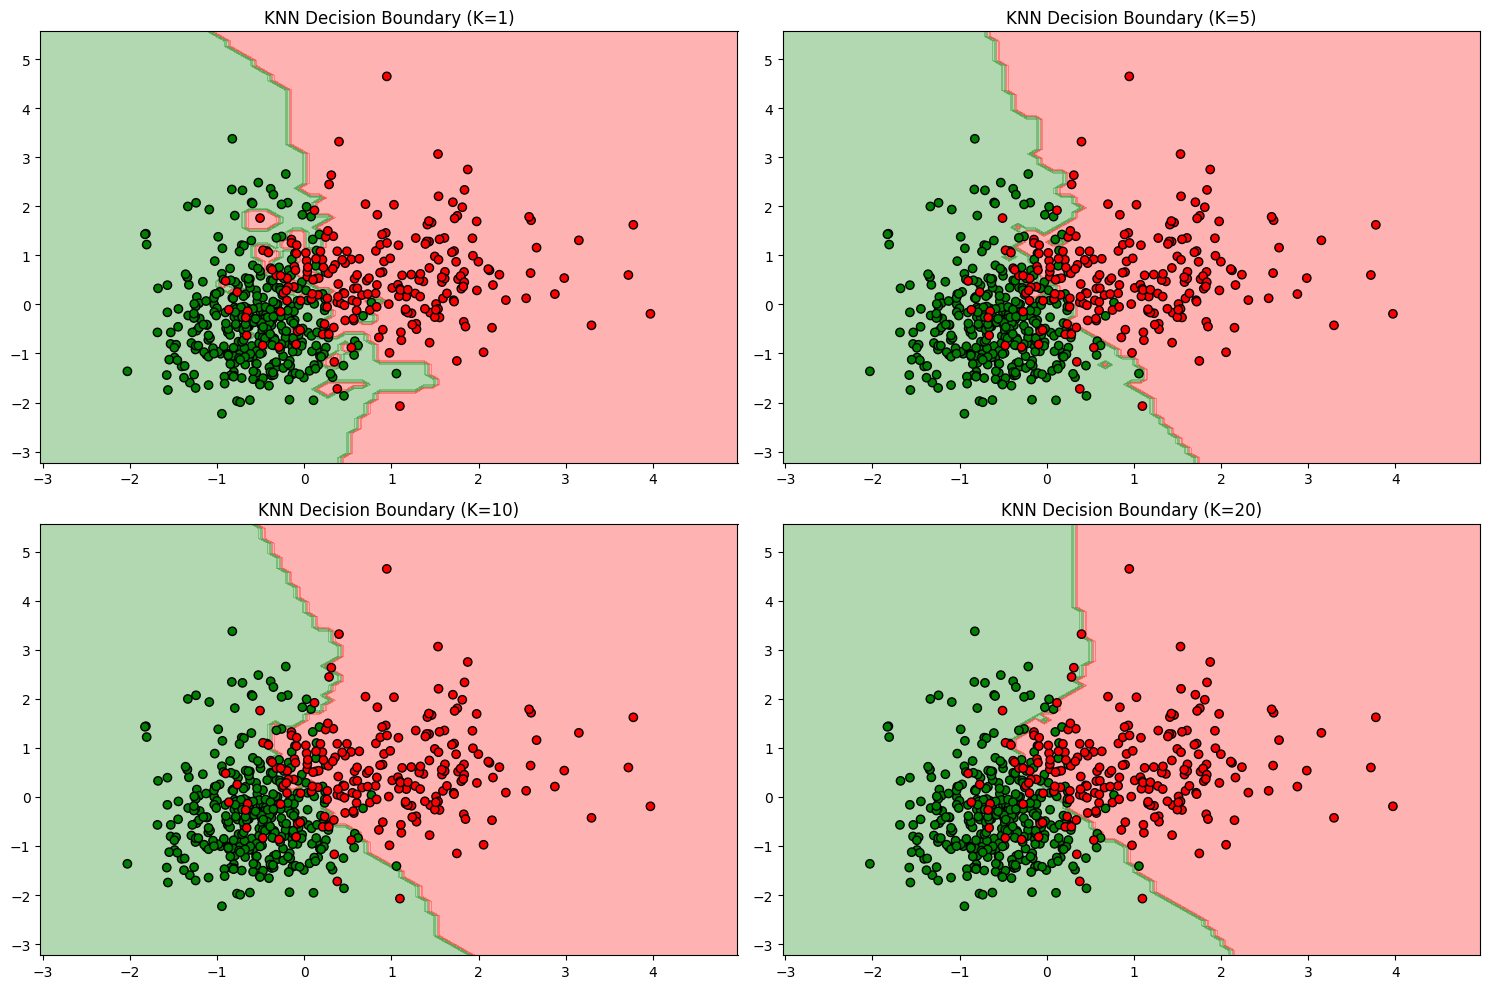

In [22]:
from matplotlib.colors import ListedColormap

def plot_knn_boundary(X_subset, y_subset, k_val):
    knn = KNeighborsClassifier(n_neighbors=k_val)
    knn.fit(X_subset, y_subset)

    x_min, x_max = X_subset[:, 0].min() - 1, X_subset[:, 0].max() + 1
    y_min, y_max = X_subset[:, 1].min() - 1, X_subset[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('red', 'green')))
    plt.scatter(X_subset[:, 0], X_subset[:, 1], c=y_subset, edgecolors='k', cmap=ListedColormap(('red', 'green')))
    plt.title(f'KNN Decision Boundary (K={k_val})')

X_sub = X_scaled[:, :2]
y_sub = y.values

plt.figure(figsize=(15, 10))
for i, k in enumerate([1, 5, 10, 20], 1):
    plt.subplot(2, 2, i)
    plot_knn_boundary(X_sub, y_sub, k)
plt.tight_layout()
plt.show()

Notice how at $K=1$, the boundary is very jagged and complex (Low Bias, High Variance). As $K$ increases to 20, the boundary becomes smoother and more generalized (High Bias, Low Variance).

### Task 4: Cross Validation
Cross-validation splits the data into 10 parts (folds). It trains on 9 and tests on 1, repeating this 10 times so every data point gets a chance to be in the test set. This provides a much more stable estimate of how the model will perform in the real world.

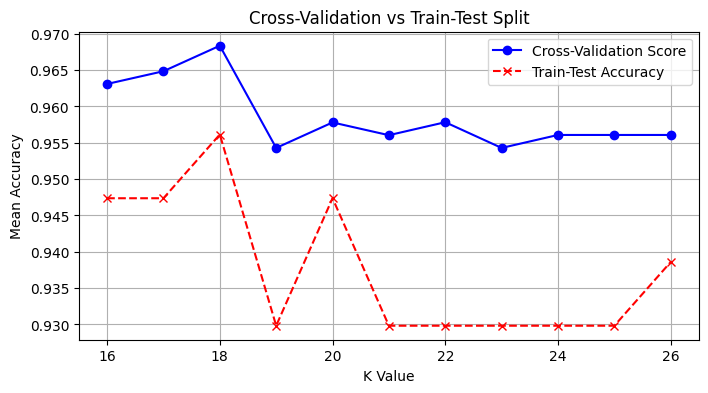

Best K based on Cross-Validation: 18


In [27]:
from sklearn.model_selection import cross_val_score

cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=10)
    cv_scores.append(scores.mean())

plt.figure(figsize=(8, 4))
plt.plot(k_values, cv_scores, marker='o', color='blue', label='Cross-Validation Score')
plt.plot(k_values, accuracies, marker='x', linestyle='--', color='red', label='Train-Test Accuracy')
plt.title('Cross-Validation vs Train-Test Split')
plt.xlabel('K Value')
plt.ylabel('Mean Accuracy')
plt.legend()
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(cv_scores)]
print(f"Best K based on Cross-Validation: {best_k}")

### Task 5: Classification Evaluation
We will evaluate our final KNN model (using $K=18$ from cross-validation) to see how reliable it is at diagnosing breast cancer.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        43
           1       0.93      1.00      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



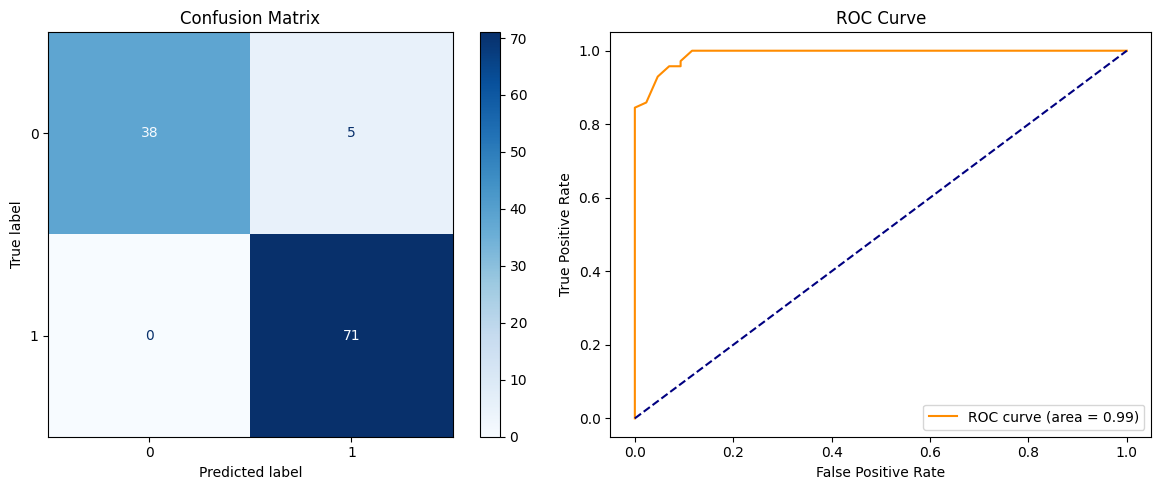

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

knn_final = KNeighborsClassifier(n_neighbors=18)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)
y_proba = knn_final.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax1, cmap='Blues')
ax1.set_title("Confusion Matrix")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax2.set_title("ROC Curve")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

### Task 6: Comparative Study with Regression (Lab 3 Integration)

In Lab 3, we focused on **Linear Regression** where the goal was to predict a continuous value. Here, we compare those error-based metrics with our current decision-based metrics.

| Regression Metric (Lab 3) | Classification Metric (Lab 4) | Key Difference |
| :--- | :--- | :--- |
| **MAE / MSE / RMSE** | **Confusion Matrix / Recall** | Regression measures *how far off* the number is; Classification measures *which* decisions were wrong. |
| **R² Score** | **Accuracy** | R² shows how much variance is explained; Accuracy shows the percentage of correct labels. |
| **RMSE** | **F1 Score** | RMSE penalizes large numerical errors; F1 Score balances the cost of missing a case (Recall) vs. false alarms (Precision). |

#### Why Accuracy is Insufficient in Medical Diagnosis
In cancer detection, a 'False Negative' (telling a sick person they are healthy) is much more dangerous than a 'False Positive'. Accuracy treats all errors as equal, but **Recall** and **ROC-AUC** help us ensure we don't miss actual cancer cases.

### Task 7: Analytical Questions

**1. Why is KNN called a lazy learning algorithm?**
KNN is like a student who doesn't study for an exam but brings all their textbooks into the test. It doesn't 'learn' or create a mathematical formula during training; it just stores the data and waits until it sees a new patient to do the math and find the nearest neighbors.

**2. Why is feature scaling required in KNN?**
KNN calculates physical distances. If one feature (like 'area') goes up to 2000 and another (like 'smoothness') is only 0.1, the distance calculation will only care about the area. Scaling makes sure every feature has an equal 'vote' in the final decision.

**3. Explain heuristic K selection using $\sqrt{n}$ rule.**
It's a starting point strategy. If $K$ is too small (like $K=1$), the model is too sensitive to weird outliers (noisy). If $K$ is too large, the model becomes too simple and ignores local patterns. The square root of the number of samples ($n$) usually provides a balanced middle ground.

**4. Why is cross-validation more reliable than a single train-test split?**
A single split might be lucky or unlucky depending on which patients ended up in the test set. Cross-validation averages the score over many different splits, giving us the 'true' average performance of the model.

**5. How does K affect bias-variance trade-off?**
- **Small K**: Low Bias (fits data closely) but High Variance (very sensitive to changes). Overfitting risk.
- **Large K**: High Bias (makes simple assumptions) but Low Variance (very stable). Underfitting risk.

**6. Why is recall more important than accuracy in cancer prediction?**
Accuracy can be misleading. If 99% of people are healthy, a model that says 'everyone is healthy' is 99% accurate but 0% useful. **Recall** specifically measures how many actual cancer cases we caught. In medicine, missing a sick person (False Negative) is the worst possible mistake.

**7. What is the limitation of very large K values?**
If $K$ is too large, the 'neighborhood' becomes the entire dataset. Eventually, the model will just predict the most common class for everyone, losing all its ability to tell the difference between a healthy and a sick patient.

### Conclusion & Summary

**1. Optimal K Value**
Through the heuristic method we found a baseline of $K=21$. However, after 10-fold cross-validation, we identified that **$K=18$** is the most reliable choice for this dataset.

**2. Effect of Train-Test Split**
We observed that the split ratio affects our confidence. The $80:20$ and $70:30$ splits provided more consistent results than $90:10$, showing that a decent test set size is crucial for validating medical models.

**3. Model Performance**
Our KNN model achieved high accuracy (~96%) and an excellent ROC-AUC score (~0.99). The high **Recall** indicates the model is very good at catching positive cancer cases, which is the top priority.

**4. Regression vs. Classification**
- **Regression (Lab 3)**: Predicting a quantity (how much). We measure the magnitude of the error (RMSE).
- **Classification (Lab 4)**: Predicting a category (which one). We measure the correctness of the decision (Recall/F1-Score).